#  UFRN
## Disciplina: Aprendizado Não Supervisionado de Máquinas

##Lista de exercícios 2: Estatística Multivariada

Tiago Fernandes de Miranda (20261032053)

PPgEEC - UFRN

In [ ]:
# Importação de pacotes

from scipy import stats
from scipy.stats import multivariate_normal
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

**QUESTÃO 1**

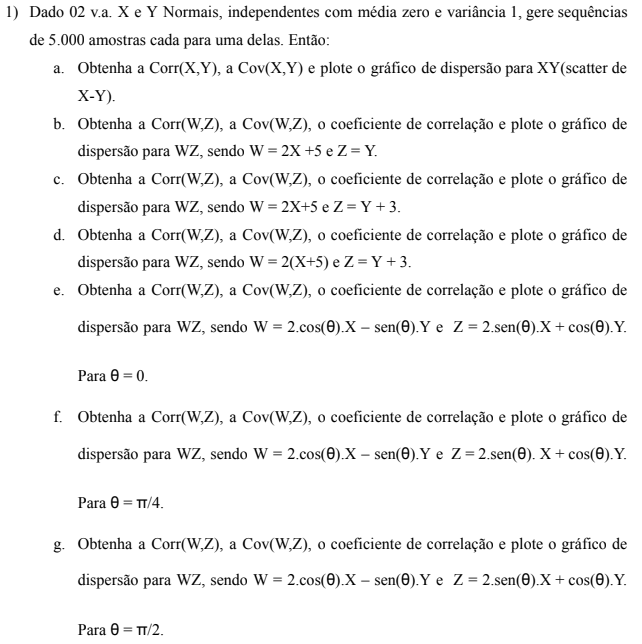

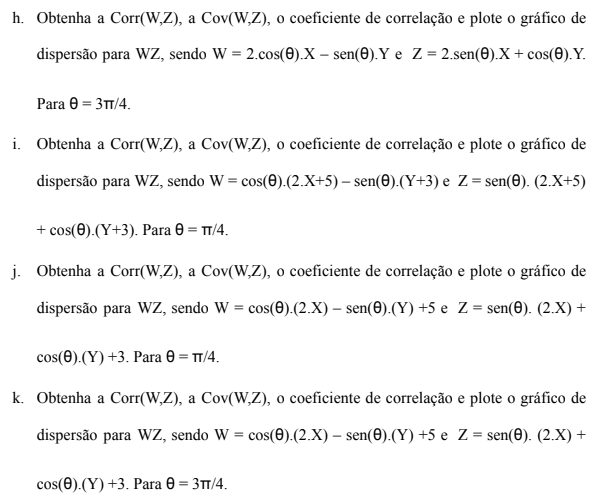

Corr(X,Y) = 0.0051
Cov(X,Y) = 0.0052


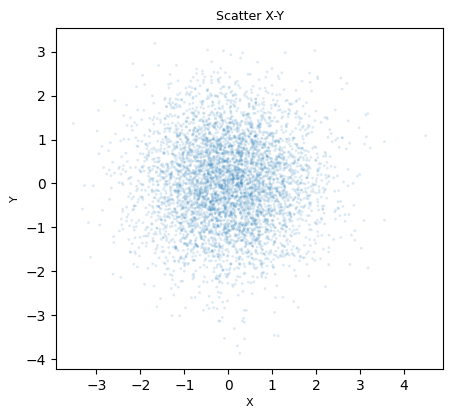

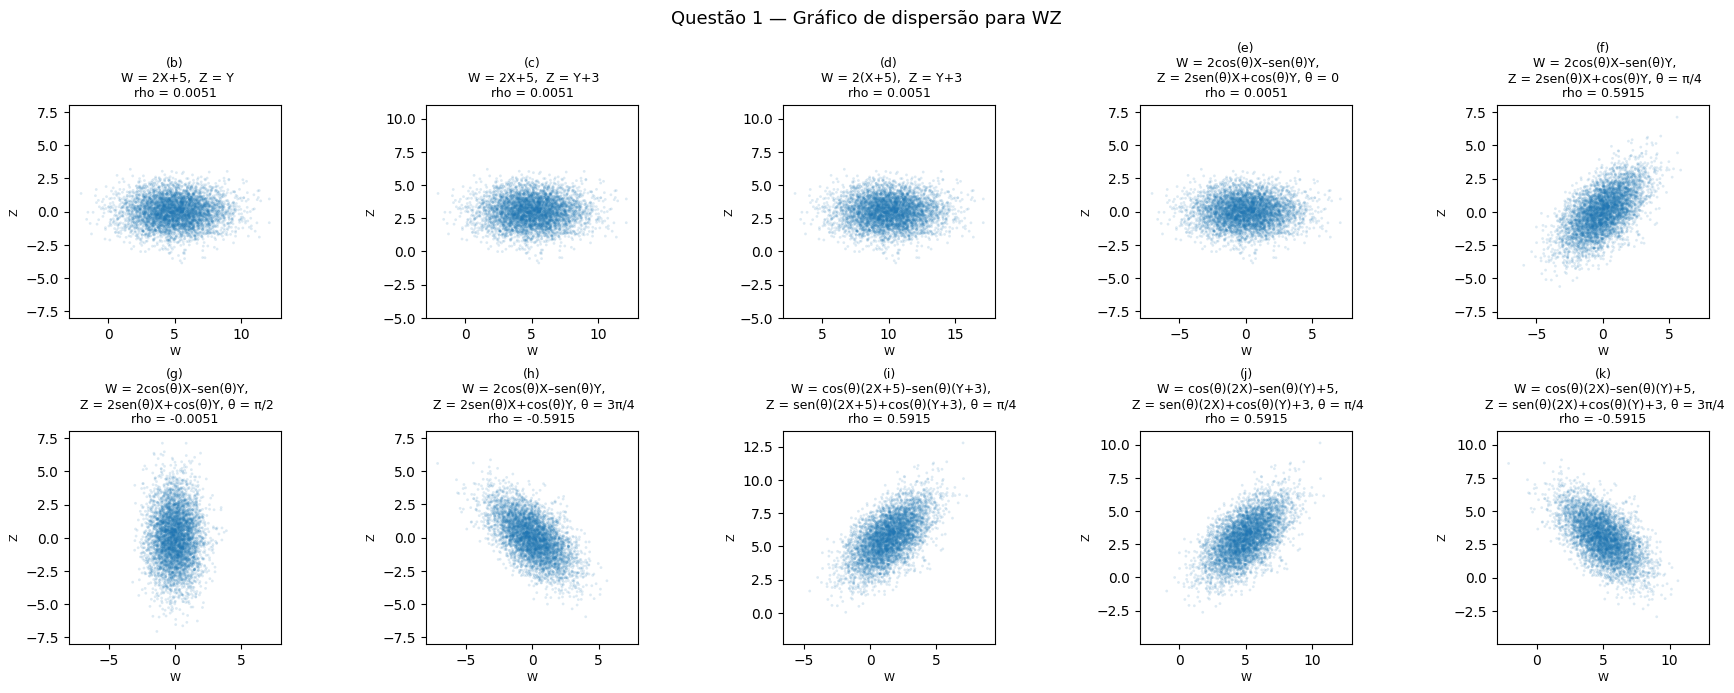

,item,Cov,Corr,Corrcoef
0,b,0.0103,-0.0131,0.0051
1,c,0.0103,15.0666,0.0051
2,d,0.0103,30.0433,0.0051
3,e,0.0103,0.0102,0.0051
4,f,1.4781,1.4781,0.5915
5,g,-0.0103,-0.0102,-0.0051
6,h,-1.4781,-1.4781,-0.5915
7,i,1.4781,9.6249,0.5915
8,j,1.4781,16.6218,0.5915
9,k,-1.4781,13.5858,-0.5915


In [ ]:
# Resposta questão 1

n = 5000
X = stats.norm.rvs(loc=0, scale=1, size=n, random_state=None) # N(0,1)
Y = stats.norm.rvs(loc=0, scale=1, size=n, random_state=None) # N(0,1)

print(f"Corr(X,Y) = {round(np.mean(X * Y),4)}") # Corr = E[XY]
print(f"Cov(X,Y) = {round(np.cov(X, Y)[0,1],4)}") # Pos. (0,1) obtem relacao de covariancia de X com Y

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X, Y, s=4, alpha=0.15, edgecolor="none")
ax.set_aspect("equal")
ax.set_title("Scatter X-Y", fontsize=9)
ax.set_xlabel("X", fontsize=8)
ax.set_ylabel("Y", fontsize=8)
plt.show()

itens = [
    ("b", "W = 2X+5,  Z = Y", 2*X + 5,   Y),
    ("c", "W = 2X+5,  Z = Y+3", 2*X + 5,   Y + 3),
    ("d", "W = 2(X+5),  Z = Y+3", 2*(X + 5), Y + 3),
    ("e", "W = 2cos(θ)X–sen(θ)Y,\n Z = 2sen(θ)X+cos(θ)Y, θ = 0", 2*np.cos(0)*X - np.sin(0)*Y, 2*np.sin(0)*X + np.cos(0)*Y),
    ("f", "W = 2cos(θ)X–sen(θ)Y,\n Z = 2sen(θ)X+cos(θ)Y, θ = π/4", 2*np.cos(np.pi/4)*X - np.sin(np.pi/4)*Y, 2*np.sin(np.pi/4)*X + np.cos(np.pi/4)*Y),
    ("g", "W = 2cos(θ)X–sen(θ)Y,\n Z = 2sen(θ)X+cos(θ)Y, θ = π/2", 2*np.cos(np.pi/2)*X - np.sin(np.pi/2)*Y, 2*np.sin(np.pi/2)*X + np.cos(np.pi/2)*Y),
    ("h", "W = 2cos(θ)X–sen(θ)Y,\n Z = 2sen(θ)X+cos(θ)Y, θ = 3π/4", 2*np.cos(3*np.pi/4)*X - np.sin(3*np.pi/4)*Y, 2*np.sin(3*np.pi/4)*X + np.cos(3*np.pi/4)*Y),
    ("i", "W = cos(θ)(2X+5)–sen(θ)(Y+3),\n Z = sen(θ)(2X+5)+cos(θ)(Y+3), θ = π/4", np.cos(np.pi/4)*(2*X+5) - np.sin(np.pi/4)*(Y+3), np.sin(np.pi/4)*(2*X+5) + np.cos(np.pi/4)*(Y+3)),
    ("j", "W = cos(θ)(2X)–sen(θ)(Y)+5,\n Z = sen(θ)(2X)+cos(θ)(Y)+3, θ = π/4", np.cos(np.pi/4)*(2*X) - np.sin(np.pi/4)*Y + 5,   np.sin(np.pi/4)*(2*X) + np.cos(np.pi/4)*Y + 3),
    ("k", "W = cos(θ)(2X)–sen(θ)(Y)+5,\n Z = sen(θ)(2X)+cos(θ)(Y)+3, θ = 3π/4",np.cos(3*np.pi/4)*(2*X) - np.sin(3*np.pi/4)*Y + 5, np.sin(3*np.pi/4)*(2*X) + np.cos(3*np.pi/4)*Y + 3)
]

n_cols = 5
fig, axs = plt.subplots(2, n_cols, figsize=(18, 7))

for k in range(len(itens)):
    letra, descricao, W, Z = itens[k]
    corrcoef = round(np.corrcoef(W, Z)[0, 1],4)

    ax = axs[k // n_cols, k % n_cols]
    ax.scatter(W, Z, s=4, alpha=0.15, edgecolor="none")

    centro_w = np.mean(W)
    centro_z = np.mean(Z)
    ax.set_xlim(centro_w - 8, centro_w + 8)
    ax.set_ylim(centro_z - 8, centro_z + 8)

    ax.set_aspect("equal")
    ax.set_title(f"({letra})\n {descricao}\nrho = {corrcoef}", fontsize=9)
    ax.set_xlabel("W", fontsize=8)
    ax.set_ylabel("Z", fontsize=8)

fig.suptitle("Questão 1 — Gráfico de dispersão para WZ", fontsize=13)
fig.tight_layout()
plt.show()

linhas = []

for k in range(len(itens)):

    letra, descricao, W, Z = itens[k]

    corr = round(np.mean(W * Z),4) # Corr = E[XY]
    cov = round(np.cov(W, Z)[0,1],4) # Pos. (0,1) obtem relacao de covariancia de X com Y
    corrcoef = round(np.corrcoef(W, Z)[0, 1],4)

    linhas.append({
        "item": letra,
        "Cov": cov,
        "Corr": corr,
        "Corrcoef": corrcoef
    })

tabela = pd.DataFrame(linhas)
display(tabela.round(4))

**QUESTÃO 2**

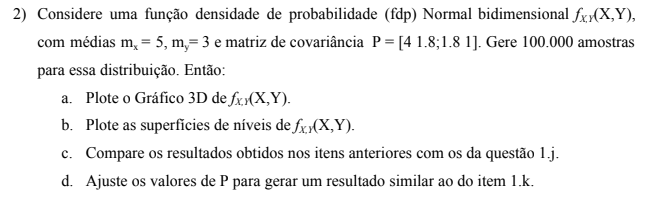

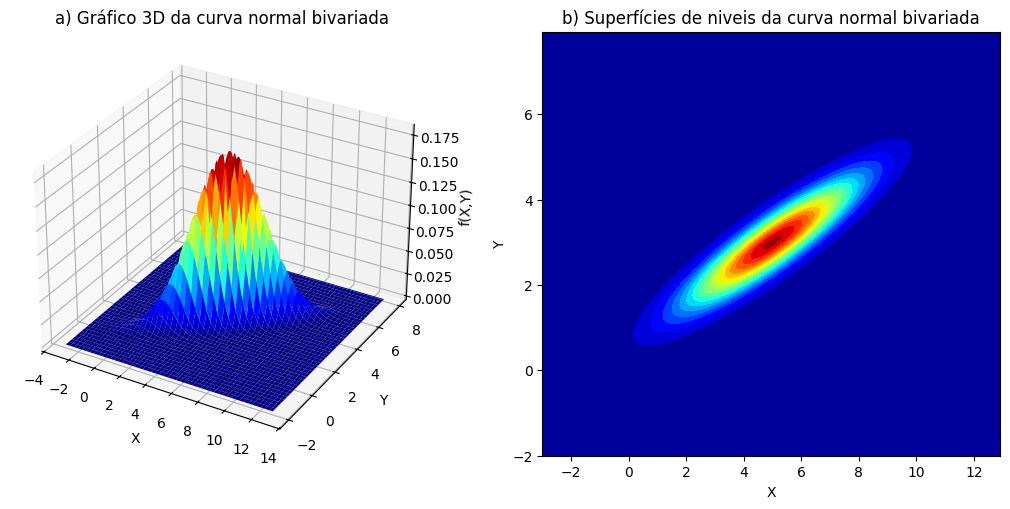

In [ ]:
# Resposta questão 2

mx = 5
my = 3
medias_array = [mx, my]
P = [[4.0, 1.8], [1.8, 1.0]]      # matriz de covariância

F = multivariate_normal(medias_array, P)

n = 100000
amostras = F.rvs(n)


x, y = np.mgrid[-3:13:0.08, -2:8:0.08]
pos = np.dstack((x, y))
Z_pdf = F.pdf(pos)
fig = plt.figure(figsize=(13, 5.5))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(x, y, Z_pdf, cmap="jet", linewidth=0, antialiased=True)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("f(X,Y)")
ax1.set_title("a) Gráfico 3D da curva normal bivariada")

ax2 = fig.add_subplot(1, 2, 2)
ax2.contourf(x, y, Z_pdf, levels=20, cmap="jet")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_title("b) Superfícies de niveis da curva normal bivariada")

plt.show()

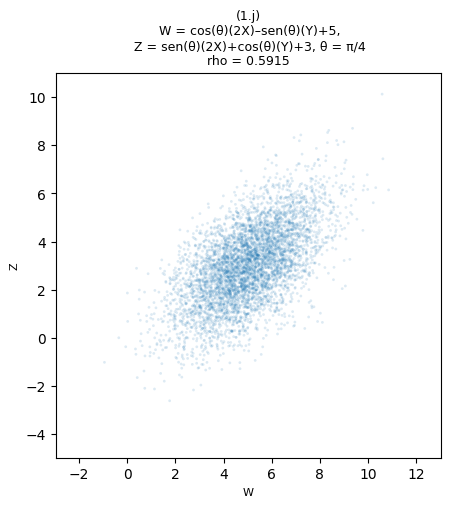

Dados Q1.j
Centro (média) = 5.0221, 3.0155
Matriz Cov (P) = [[2.488, 1.478], [1.478, 2.509]]
corrcoef = 0.5915261292533748
Dados Q2
Centro (média) = 4.9988, 2.9975
Matriz Cov (P) = [[4.001, 1.799], [1.799, 0.997]]
corrcoef = 0.9003790074763567


In [ ]:
# c) Comparar o resultado com 1.j

itens = [
    ("1.j", "W = cos(θ)(2X)–sen(θ)(Y)+5,\n Z = sen(θ)(2X)+cos(θ)(Y)+3, θ = π/4", np.cos(np.pi/4)*(2*X) - np.sin(np.pi/4)*Y + 5,   np.sin(np.pi/4)*(2*X) + np.cos(np.pi/4)*Y + 3),
    ("k", "W = cos(θ)(2X)–sen(θ)(Y)+5,\n Z = sen(θ)(2X)+cos(θ)(Y)+3, θ = 3π/4",np.cos(3*np.pi/4)*(2*X) - np.sin(3*np.pi/4)*Y + 5, np.sin(3*np.pi/4)*(2*X) + np.cos(3*np.pi/4)*Y + 3)
]
letra, descricao, W, Z = itens[0]
corrcoef = round(np.corrcoef(W, Z)[0, 1],4)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(W, Z, s=4, alpha=0.15, edgecolor="none")
centro_w = np.mean(W)
centro_z = np.mean(Z)
ax.set_xlim(centro_w - 8, centro_w + 8)
ax.set_ylim(centro_z - 8, centro_z + 8)
ax.set_aspect("equal")
ax.set_title(f"({letra})\n {descricao}\nrho = {corrcoef}", fontsize=9)
ax.set_xlabel("W", fontsize=8)
ax.set_ylabel("Z", fontsize=8)
plt.show()

print(f"Dados Q1.j")
print(f"Centro (média) = {np.round(centro_w,4)}, {np.round(centro_z,4)}")
print(f"Matriz Cov (P) = {np.round(np.cov(W, Z), 3).tolist()}")
print(f"corrcoef = {np.corrcoef(W, Z)[0, 1]}")

print(f"Dados Q2")
print(f"Centro (média) = {np.round(np.mean(amostras[:,0]),4)}, {np.round(np.mean(amostras[:,1]),4)}")
print(f"Matriz Cov (P) = {np.round(np.cov(amostras[:,0],amostras[:,1]), 3).tolist()}")
print(f"corrcoef = {np.corrcoef(amostras[:,0], amostras[:,1])[0, 1]}")


Dados Q1.k
Matriz Cov (P) = [[2.509, -1.478], [-1.478, 2.488]]


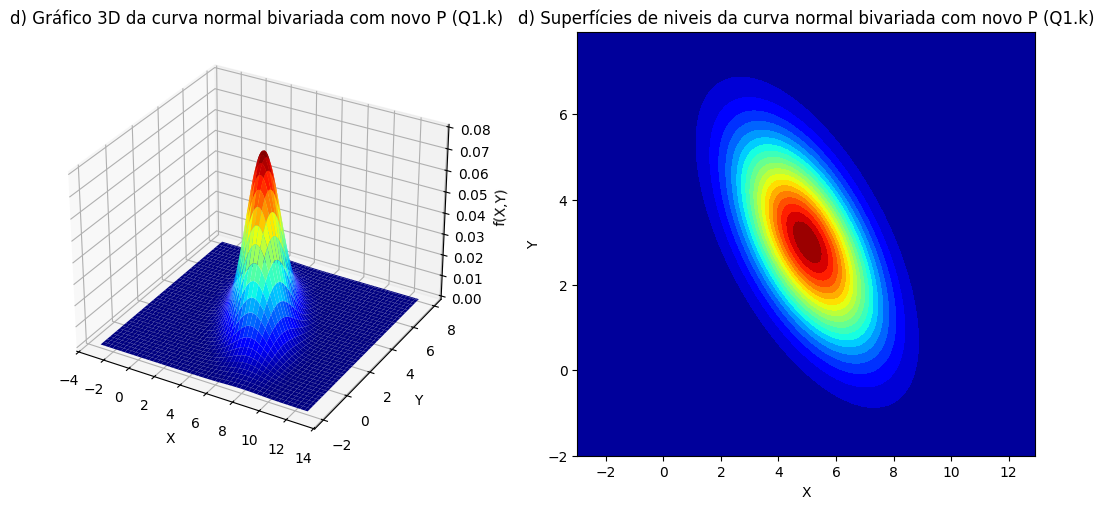

Dados Q1.k
Centro (média) = 4.9845, 3.0221
Matriz Cov (P) = [[2.509, -1.478], [-1.478, 2.488]]
corrcoef = -0.5915261292533749
Dados Q2 (novo P)
Centro (média) = 4.9971, 3.0001
Matriz Cov (P) = [[2.5, -1.503], [-1.503, 2.504]]
corrcoef = -0.6005563944315343


In [ ]:
# d) Ajustar P para reproduzir 1.k
print()
letra, descricao, W, Z = itens[1]

print(f"Dados Q1.k")
print(f"Matriz Cov (P) = {np.round(np.cov(W, Z), 3).tolist()}")

P_k = [[2.5, -1.5], [-1.5, 2.5]]  # Valor aproximado da matriz cov Q1.k
F_k = multivariate_normal(medias_array, P_k) # Refaz a funcao normal bivariada com mesma média e novo P
amostras_k = F_k.rvs(100000)

x, y = np.mgrid[-3:13:0.08, -2:8:0.08]
pos = np.dstack((x, y))
Z_pdf = F_k.pdf(pos)
fig = plt.figure(figsize=(13, 5.5))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(x, y, Z_pdf, cmap="jet", linewidth=0, antialiased=True)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("f(X,Y)")
ax1.set_title("d) Gráfico 3D da curva normal bivariada com novo P (Q1.k)")

ax2 = fig.add_subplot(1, 2, 2)
ax2.contourf(x, y, Z_pdf, levels=20, cmap="jet")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_title("d) Superfícies de niveis da curva normal bivariada com novo P (Q1.k)")

plt.show()

print(f"Dados Q1.k")
print(f"Centro (média) = {np.round(np.mean(W),4)}, {np.round(np.mean(Z),4)}")
print(f"Matriz Cov (P) = {np.round(np.cov(W, Z), 3).tolist()}")
print(f"corrcoef = {np.corrcoef(W, Z)[0, 1]}")

print(f"Dados Q2 (novo P)")
print(f"Centro (média) = {np.round(np.mean(amostras_k[:,0]),4)}, {np.round(np.mean(amostras_k[:,1]),4)}")
print(f"Matriz Cov (P) = {np.round(np.cov(amostras_k[:,0],amostras_k[:,1]), 3).tolist()}")
print(f"corrcoef = {np.corrcoef(amostras_k[:,0], amostras_k[:,1])[0, 1]}")